<a href="https://colab.research.google.com/github/bautistacoyotecatl1-svg/Modulo-2-Modelos-Estadisticos/blob/main/01_Espacios_de_probabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Espacios de probabilidad

## Fundamentos, enfoques y simulación


**Bautista Coyotecatl Gerardo**  

  

Este cuaderno construye el lenguaje de la probabilidad desde el experimento aleatorio hasta la independencia. Combina razonamiento con conjuntos, cálculo manual, simulación y visualización.

## Tabla de contenidos

1. [Introducción](#1-introducción)
2. [Objetivos de aprendizaje](#2-objetivos-de-aprendizaje)
3. [Experimentos, resultados y espacio muestral](#3-experimentos-resultados-y-espacio-muestral)
4. [Eventos y operaciones](#4-eventos-y-operaciones)
5. [Familia de eventos y espacio de probabilidad](#5-familia-de-eventos-y-espacio-de-probabilidad)
6. [Axiomas y propiedades](#6-axiomas-y-propiedades)
7. [Tres enfoques de probabilidad](#7-tres-enfoques-de-probabilidad)
8. [Problema del encuentro](#8-problema-del-encuentro)
9. [Probabilidad condicional y regla del producto](#9-probabilidad-condicional-y-regla-del-producto)
10. [Probabilidad total](#10-probabilidad-total)
11. [Independencia y exclusión mutua](#11-independencia-y-exclusión-mutua)
12. [Ejemplos completos](#12-ejemplos-completos)
13. [Ejemplo contextualizado](#13-ejemplo-contextualizado)
14. [Probabilidad teórica y experimental](#14-probabilidad-teórica-y-experimental)
15. [Laboratorio integrador modificable](#15-laboratorio-integrador-modificable)
16. [Conclusiones](#16-conclusiones)
17. [Bibliografía](#17-bibliografía)

## Configuración e importaciones

Se usa un único generador pseudoaleatorio con semilla fija. Esto permite reproducir exactamente las simulaciones.

In [ ]:
from itertools import product
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(123)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

## 1. Introducción

La probabilidad proporciona un lenguaje matemático para estudiar fenómenos cuyo resultado individual no puede anticiparse con certeza. El punto de partida no es una fórmula aislada, sino una descripción precisa de:

- qué experimento se realiza;
- cuáles resultados pueden ocurrir;
- qué conjuntos de resultados interesan;
- cómo se asigna probabilidad a esos conjuntos.

Esta construcción conduce al **espacio de probabilidad** $(\Omega,\mathcal{F},P)$. Los enfoques clásico, frecuentista y geométrico no compiten entre sí: son maneras de calcular o interpretar $P$ bajo condiciones distintas.

## 2. Objetivos de aprendizaje

Al finalizar, se podrá:

1. distinguir fenómenos determinísticos y aleatorios;
2. construir $\Omega$ y representar eventos como subconjuntos;
3. operar eventos mediante unión, intersección, complemento y diferencia;
4. explicar la terna $(\Omega,\mathcal{F},P)$ y los axiomas de Kolmogórov;
5. aplicar los enfoques laplaciano, frecuentista y geométrico;
6. calcular probabilidades condicionales, totales y mediante la regla del producto;
7. diferenciar independencia de exclusión mutua;
8. contrastar resultados teóricos con simulaciones reproducibles.

## 3. Experimentos, resultados y espacio muestral

### 3.1 Determinístico frente a aleatorio

Un experimento es **determinístico** cuando las mismas condiciones conducen al mismo resultado dentro del modelo considerado. Por ejemplo, convertir $20\,^\circ\mathrm{C}$ a grados Fahrenheit siempre produce $68\,^\circ\mathrm{F}$.

Un experimento es **aleatorio** cuando puede producir distintos resultados aun al repetirse bajo condiciones similares y no se conoce de antemano cuál ocurrirá. Lanzar un dado es el ejemplo básico.

> Aleatorio no significa “sin reglas”: los resultados posibles y sus probabilidades pueden modelarse con precisión.

### 3.2 Resultado elemental y espacio muestral

Un **resultado elemental** se denota por $\omega$. El conjunto de todos los resultados posibles es el **espacio muestral**:

$$\Omega=\{\omega:\omega\text{ puede resultar del experimento}\}.$$

Ejemplos:

- moneda: $\Omega=\{\text{águila},\text{sol}\}$;
- dado: $\Omega=\{1,2,3,4,5,6\}$;
- dos dados: $\Omega=\{(i,j):i,j\in\{1,\ldots,6\}\}$;
- tiempo de espera: $\Omega=[0,\infty)$.

In [ ]:
# Espacio muestral de dos dados distinguibles
omega_dados = list(product(range(1, 7), repeat=2))
pd.DataFrame(omega_dados, columns=["dado_1", "dado_2"]).head(8)

,dado_1,dado_2
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
5,1,6
6,2,1
7,2,2


Los dados son distinguibles: $(2,5)$ y $(5,2)$ son resultados distintos. Por ello $|\Omega|=6^2=36$.

In [ ]:
len(omega_dados)

36

## 4. Eventos y operaciones

Un **evento** es un subconjunto de $\Omega$. Ocurre cuando el resultado observado pertenece a ese subconjunto.

- evento elemental: contiene un resultado;
- evento compuesto: contiene más de uno;
- evento seguro: $\Omega$;
- evento imposible: $\varnothing$.

Para un dado, sean $A=\{2,4,6\}$ (“sale par”) y $B=\{4,5,6\}$ (“sale al menos 4”).

| Operación | Notación | Lectura |
|---|---:|---|
| Unión | $A\cup B$ | ocurre $A$, $B$ o ambos |
| Intersección | $A\cap B$ | ocurren ambos |
| Complemento | $A^c$ | no ocurre $A$ |
| Diferencia | $A\setminus B$ | ocurre $A$ pero no $B$ |

In [ ]:
omega_dado = set(range(1, 7))
A = {2, 4, 6}
B = {4, 5, 6}

operaciones = {
    "A ∪ B": A | B,
    "A ∩ B": A & B,
    "Aᶜ": omega_dado - A,
    "A \ B": A - B,
}
pd.Series({k: sorted(v) for k, v in operaciones.items()}, name="resultados")

<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3525/3823295311.py:9: SyntaxWarning: invalid escape sequence '\ '
  "A \ B": A - B,


,resultados
A ∪ B,"[2, 4, 5, 6]"
A ∩ B,"[4, 6]"
Aᶜ,"[1, 3, 5]"
A \ B,[2]


Dos eventos son **mutuamente excluyentes** si $A\cap B=\varnothing$. Las leyes de De Morgan permiten transformar complementos:

$$
(A\cup B)^c=A^c\cap B^c,\qquad
(A\cap B)^c=A^c\cup B^c.
$$

**Actividad breve.** Modifica $A$ y $B$ en la celda anterior y comprueba ambas leyes mediante igualdad de conjuntos.

## 5. Familia de eventos y espacio de probabilidad

No siempre se asigna probabilidad a cualquier subconjunto imaginable. Se selecciona una familia $\mathcal{F}$ de eventos que satisface:

1. $\Omega\in\mathcal{F}$;
2. si $A\in\mathcal{F}$, entonces $A^c\in\mathcal{F}$;
3. si $A_1,A_2,\ldots\in\mathcal{F}$, entonces $\bigcup_{n=1}^{\infty}A_n\in\mathcal{F}$.

Una familia con estas propiedades se llama **$\sigma$-álgebra**. Por las reglas anteriores también contiene $\varnothing$ y es cerrada bajo intersecciones numerables. En espacios finitos suele emplearse el conjunto potencia $\mathcal{P}(\Omega)$.

Un **espacio de probabilidad** es la terna

$$
(\Omega,\mathcal{F},P),
$$

donde:

- $\Omega$ es el espacio muestral;
- $\mathcal{F}$ es la familia de eventos;
- $P:\mathcal{F}\to[0,1]$ es una medida de probabilidad.

Para una moneda equilibrada:

$$
\Omega=\{A,S\},\quad
\mathcal{F}=\{\varnothing,\{A\},\{S\},\Omega\},\quad
P(\{A\})=P(\{S\})=\tfrac12.
$$

## 6. Axiomas y propiedades

### 6.1 Axiomas de Kolmogórov

Para eventos $A,A_1,A_2,\ldots\in\mathcal{F}$:

1. **No negatividad:** $P(A)\ge 0$.
2. **Normalización:** $P(\Omega)=1$.
3. **Aditividad numerable:** si $A_i\cap A_j=\varnothing$ para $i\ne j$, entonces

$$
P\left(\bigcup_{i=1}^{\infty}A_i\right)=\sum_{i=1}^{\infty}P(A_i).
$$

El hecho de que $P(A)\le 1$ es una propiedad derivada, no necesita formularse como axioma adicional.

### 6.2 Propiedades derivadas

De los axiomas se obtienen:

$$
\begin{aligned}
P(\varnothing)&=0,\\
P(A^c)&=1-P(A),\\
A\subseteq B&\Rightarrow P(A)\le P(B),\\
P(B\setminus A)&=P(B)-P(A),\quad A\subseteq B,\\
P(A\cup B)&=P(A)+P(B)-P(A\cap B).
\end{aligned}
$$

La última expresión evita contar dos veces la intersección.

In [ ]:
def p_laplaciana(evento, omega):
    # Probabilidad exacta cuando los resultados de omega son equiprobables.
    return Fraction(len(evento), len(omega))

p_union = p_laplaciana(A | B, omega_dado)
p_inclusion = (
    p_laplaciana(A, omega_dado)
    + p_laplaciana(B, omega_dado)
    - p_laplaciana(A & B, omega_dado)
)
pd.Series({"P(A ∪ B)": str(p_union), "Inclusión-exclusión": str(p_inclusion)})

,0
P(A ∪ B),2/3
Inclusión-exclusión,2/3


Ambos cálculos producen el mismo valor, lo que verifica la regla de inclusión-exclusión en este ejemplo.

## 7. Tres enfoques de probabilidad

### 7.1 Enfoque clásico o laplaciano

Si $\Omega$ es finito y sus resultados elementales son equiprobables,

$$P(A)=\frac{|A|}{|\Omega|}
=\frac{\text{casos favorables}}{\text{casos posibles}}.$$

La equiprobabilidad es una condición esencial. No basta contar resultados si estos tienen probabilidades distintas.

**Ejemplo manual.** En un dado equilibrado, $P(\text{par})=3/6=1/2$.

In [ ]:
p_laplaciana(A, omega_dado)

Fraction(1, 2)

### 7.2 Enfoque frecuentista

Al repetir $n$ veces un experimento bajo condiciones estables, la frecuencia relativa de $A$ es

$$f_n(A)=\frac{N_n(A)}{n},$$

donde $N_n(A)$ cuenta las ocurrencias de $A$. Para $n$ grande, $f_n(A)$ suele aproximarse a $P(A)$. Una simulación ilustra esta estabilización, pero no sustituye una demostración matemática.

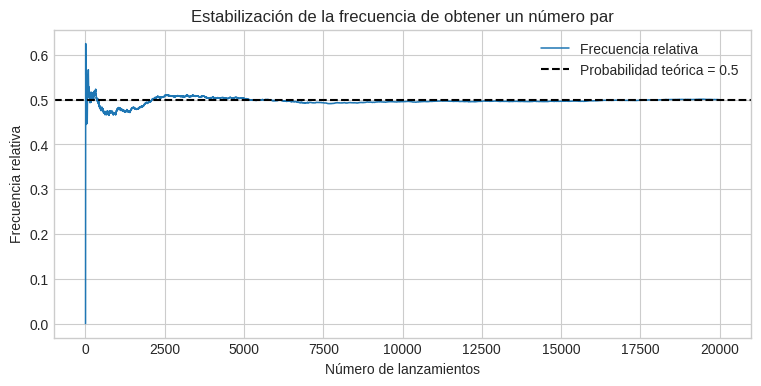

In [ ]:
n = 20_000
lanzamientos = rng.integers(1, 7, size=n)
es_par = lanzamientos % 2 == 0
frecuencia_acumulada = np.cumsum(es_par) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, n + 1), frecuencia_acumulada, lw=1.1, label="Frecuencia relativa")
ax.axhline(0.5, color="black", ls="--", label="Probabilidad teórica = 0.5")
ax.set(title="Estabilización de la frecuencia de obtener un número par",
       xlabel="Número de lanzamientos", ylabel="Frecuencia relativa")
ax.legend()
plt.show()

Al inicio hay oscilaciones grandes porque cada resultado pesa mucho. Al aumentar el número de lanzamientos, la frecuencia se estabiliza alrededor de $0.5$.

### 7.3 Enfoque geométrico

Cuando un punto se distribuye uniformemente en una región $R$, la probabilidad de caer en una subregión $A$ es la razón entre sus medidas:

$$P(A)=\frac{\mu(A)}{\mu(R)},$$

donde $\mu$ puede representar longitud, área o volumen. La uniformidad respecto de la medida elegida es indispensable.

## 8. Problema del encuentro

Dos personas llegan, de manera independiente y uniforme, entre los minutos $0$ y $60$. Cada una espera $10$ minutos. Si $X$ y $Y$ son sus tiempos de llegada, se encuentran cuando

$$|X-Y|\le 10.$$

El espacio total es el cuadrado $[0,60]^2$, de área $60^2$. El no encuentro forma dos triángulos con catetos de longitud $50$. Por tanto,

$$
P(\text{encuentro})
=1-\frac{2(50^2/2)}{60^2}
=1-\frac{2500}{3600}
=\frac{11}{36}\approx0.3056.
$$

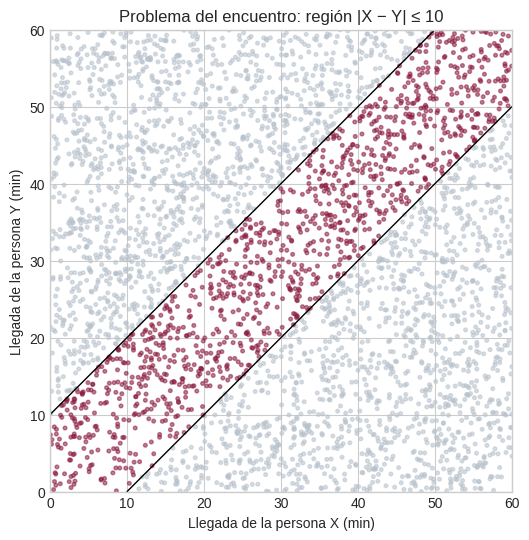

,0
probabilidad teórica,0.3056
frecuencia simulada,0.3024
error absoluto,0.0031


In [ ]:
m = 30_000
x = rng.uniform(0, 60, m)
y = rng.uniform(0, 60, m)
se_encuentran = np.abs(x - y) <= 10

fig, ax = plt.subplots(figsize=(6, 6))
muestra_grafica = 4_000
ax.scatter(x[:muestra_grafica], y[:muestra_grafica],
           c=np.where(se_encuentran[:muestra_grafica], "#8c1d40", "#b8c2cc"),
           s=7, alpha=0.55)
ax.plot([0, 50], [10, 60], color="black", lw=1)
ax.plot([10, 60], [0, 50], color="black", lw=1)
ax.set(xlim=(0, 60), ylim=(0, 60), aspect="equal",
       title="Problema del encuentro: región |X − Y| ≤ 10",
       xlabel="Llegada de la persona X (min)",
       ylabel="Llegada de la persona Y (min)")
plt.show()

pd.Series({
    "probabilidad teórica": 11/36,
    "frecuencia simulada": se_encuentran.mean(),
    "error absoluto": abs(se_encuentran.mean() - 11/36),
})

La zona color vino representa los pares de llegada que permiten encontrarse. La estimación simulada es cercana a $11/36$; la diferencia es el error aleatorio propio de una muestra finita.

## 9. Probabilidad condicional y regla del producto

Si $P(B)>0$, la probabilidad de $A$ dado que ocurrió $B$ es

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}.$$

La condición $B$ restringe el universo relevante. Al despejar se obtiene la **regla del producto**:

$$P(A\cap B)=P(A\mid B)P(B)=P(B\mid A)P(A).$$

Para una secuencia $A_1,\ldots,A_n$:

$$
P\left(\bigcap_{i=1}^n A_i\right)
=P(A_1)\prod_{i=2}^n
P\left(A_i\mid A_1\cap\cdots\cap A_{i-1}\right),
$$

si las probabilidades condicionantes están definidas.

In [ ]:
# Tres monedas: B = la primera es águila; C = exactamente dos águilas
omega_monedas_3 = set(product(("A", "S"), repeat=3))
B_moneda = {w for w in omega_monedas_3 if w[0] == "A"}
C_moneda = {w for w in omega_monedas_3 if w.count("A") == 2}

def p_condicional(evento, condicion, omega):
    if not condicion:
        raise ValueError("La condición debe tener probabilidad positiva.")
    return Fraction(len(evento & condicion), len(condicion))

pd.Series({
    "P(B | C)": str(p_condicional(B_moneda, C_moneda, omega_monedas_3)),
    "P(C | B)": str(p_condicional(C_moneda, B_moneda, omega_monedas_3)),
})

,0
P(B | C),2/3
P(C | B),1/2


$P(B\mid C)=2/3$ porque, entre los tres resultados con exactamente dos águilas, en dos la primera es águila. En cambio $P(C\mid B)=1/2$. En general, condicionar no es una operación simétrica.

## 10. Probabilidad total

Si $B_1,\ldots,B_k$ forman una partición de $\Omega$ —son mutuamente excluyentes, su unión es $\Omega$ y $P(B_i)>0$— entonces:

$$P(A)=\sum_{i=1}^{k}P(A\mid B_i)P(B_i).$$

**Ejemplo.** Una solicitud proviene del canal digital con probabilidad $0.70$ y del canal presencial con $0.30$. Las probabilidades de contener un dato incompleto son $0.04$ y $0.10$, respectivamente:

$$P(I)=0.04(0.70)+0.10(0.30)=0.058.$$

In [ ]:
canales = pd.DataFrame({
    "canal": ["digital", "presencial"],
    "P(canal)": [0.70, 0.30],
    "P(incompleta | canal)": [0.04, 0.10],
})
canales["aporte"] = canales["P(canal)"] * canales["P(incompleta | canal)"]
display(canales)
print(f"P(solicitud incompleta) = {canales['aporte'].sum():.3f}")

,canal,P(canal),P(incompleta | canal),aporte
0,digital,0.7,0.04,0.028
1,presencial,0.3,0.10,0.030


P(solicitud incompleta) = 0.058


La probabilidad total de una solicitud incompleta es $0.058$, es decir, $5.8\%$. Cada aporte combina el peso del canal y su tasa condicional.

## 11. Independencia y exclusión mutua

Los eventos $A$ y $B$ son **independientes** si

$$P(A\cap B)=P(A)P(B).$$

Si $P(B)>0$, esto equivale a $P(A\mid B)=P(A)$: conocer $B$ no modifica la probabilidad de $A$.

La **exclusión mutua** significa $A\cap B=\varnothing$. No es lo mismo:

| Concepto | Condición | Idea |
|---|---|---|
| Independencia | $P(A\cap B)=P(A)P(B)$ | un evento no aporta información sobre el otro |
| Exclusión mutua | $P(A\cap B)=0$ | no pueden ocurrir juntos |

Si $A$ y $B$ son excluyentes y ambos tienen probabilidad positiva, no pueden ser independientes, pues $0=P(A\cap B)\ne P(A)P(B)>0$.

In [ ]:
# En un dado: A = par, C = mayor que 3, D = impar
C = {4, 5, 6}
D = {1, 3, 5}

comparacion = pd.DataFrame([
    {
        "pareja": "A (par), C (>3)",
        "P(intersección)": float(p_laplaciana(A & C, omega_dado)),
        "P(E)P(F)": float(p_laplaciana(A, omega_dado) * p_laplaciana(C, omega_dado)),
        "excluyentes": len(A & C) == 0,
    },
    {
        "pareja": "A (par), D (impar)",
        "P(intersección)": float(p_laplaciana(A & D, omega_dado)),
        "P(E)P(F)": float(p_laplaciana(A, omega_dado) * p_laplaciana(D, omega_dado)),
        "excluyentes": len(A & D) == 0,
    },
])
comparacion["independientes"] = np.isclose(
    comparacion["P(intersección)"], comparacion["P(E)P(F)"]
)
comparacion

,pareja,P(intersección),P(E)P(F),excluyentes,independientes
0,"A (par), C (>3)",0.3333,0.25,False,False
1,"A (par), D (impar)",0.0000,0.25,True,False


“Par” y “mayor que 3” son independientes en este dado, aunque pueden ocurrir juntos. “Par” e “impar” son excluyentes, pero no independientes.

## 12. Ejemplos completos

### 12.1 Tres lanzamientos de una moneda

Considérese una moneda equilibrada lanzada tres veces:

$$\Omega=\{A,S\}^3,\qquad |\Omega|=8.$$

Sean:

- $E$: exactamente dos águilas;
- $F$: el primer lanzamiento es águila;
- $G$: al menos una águila.

Entonces:

$$P(E)=\frac38,\quad P(F)=\frac12,\quad P(G)=1-P(\{SSS\})=\frac78.$$

Además, $E\cap F=\{AAS,ASA\}$, de modo que $P(E\mid F)=(2/8)/(4/8)=1/2$. Como $P(E)=3/8$, $E$ y $F$ no son independientes.

In [ ]:
eventos_moneda = {
    "E: exactamente 2 A": (E := {w for w in omega_monedas_3 if w.count("A") == 2}),
    "F: primera A": (F := {w for w in omega_monedas_3 if w[0] == "A"}),
    "G: al menos 1 A": (G := {w for w in omega_monedas_3 if "A" in w}),
}

tabla_moneda = pd.DataFrame({
    "evento": eventos_moneda.keys(),
    "resultados": [sorted(v) for v in eventos_moneda.values()],
    "probabilidad": [str(p_laplaciana(v, omega_monedas_3)) for v in eventos_moneda.values()],
})
display(tabla_moneda)
print("P(E | F) =", p_condicional(E, F, omega_monedas_3))

,evento,resultados,probabilidad
0,E: exactamente 2 A,"[(A, A, S), (A, S, A), (S, A, A)]",3/8
1,F: primera A,"[(A, A, A), (A, A, S), (A, S, A), (A, S, S)]",1/2
2,G: al menos 1 A,"[(A, A, A), (A, A, S), (A, S, A), (A, S, S), (...",7/8


P(E | F) = 1/2


### 12.2 Dos dados

Sean:

- $S_7$: la suma es 7;
- $D$: aparece al menos un doble;
- $M$: la suma es mayor o igual que 10.

Para visualizar la distribución de la suma se cuentan los pares ordenados que producen cada valor.

In [ ]:
df_dados = pd.DataFrame(omega_dados, columns=["dado_1", "dado_2"])
df_dados["suma"] = df_dados["dado_1"] + df_dados["dado_2"]
tabla_sumas = (
    df_dados.groupby("suma").size()
    .rename("casos_favorables").to_frame()
    .assign(probabilidad=lambda d: d["casos_favorables"] / 36)
)
tabla_sumas

,casos_favorables,probabilidad
suma,,
2,1,0.0278
3,2,0.0556
4,3,0.0833
5,4,0.1111
6,5,0.1389
7,6,0.1667
8,5,0.1389
9,4,0.1111
10,3,0.0833


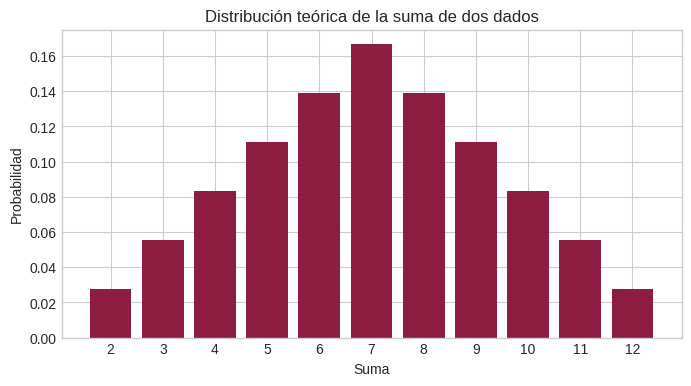

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tabla_sumas.index, tabla_sumas["probabilidad"], color="#8c1d40")
ax.set(title="Distribución teórica de la suma de dos dados",
       xlabel="Suma", ylabel="Probabilidad", xticks=range(2, 13))
plt.show()

La suma 7 es la más probable porque puede formarse de seis maneras. Las probabilidades decrecen simétricamente hacia 2 y 12.

In [ ]:
omega_dados_set = set(omega_dados)
S7 = {(i, j) for i, j in omega_dados if i + j == 7}
Dobles = {(i, j) for i, j in omega_dados if i == j}
M = {(i, j) for i, j in omega_dados if i + j >= 10}

pd.Series({
    "P(S₇)": str(p_laplaciana(S7, omega_dados_set)),
    "P(Dobles)": str(p_laplaciana(Dobles, omega_dados_set)),
    "P(M)": str(p_laplaciana(M, omega_dados_set)),
    "P(M | Dobles)": str(p_condicional(M, Dobles, omega_dados_set)),
})

,0
P(S₇),1/6
P(Dobles),1/6
P(M),1/6
P(M | Dobles),1/3


$P(M\mid\text{Dobles})=1/2$ porque, entre los seis dobles, $(4,4)$, $(5,5)$ y $(6,6)$ tienen suma al menos 10.

## 13. Ejemplo contextualizado

### Revisión documental de expedientes

En un lote de 100 expedientes:

- 60 tienen identificación completa ($I$);
- 45 tienen constancia laboral ($L$);
- 30 tienen ambos documentos.

Al seleccionar un expediente al azar:

$$
P(I\cup L)=P(I)+P(L)-P(I\cap L)
=0.60+0.45-0.30=0.75.
$$

Asimismo:

$$P(L\mid I)=\frac{P(L\cap I)}{P(I)}=\frac{0.30}{0.60}=0.50.$$

In [ ]:
resumen_expedientes = pd.Series({
    "P(I)": 0.60,
    "P(L)": 0.45,
    "P(I ∩ L)": 0.30,
    "P(I ∪ L)": 0.60 + 0.45 - 0.30,
    "P(L | I)": 0.30 / 0.60,
    "P(I)P(L)": 0.60 * 0.45,
})
resumen_expedientes

,0
P(I),0.60
P(L),0.45
P(I ∩ L),0.30
P(I ∪ L),0.75
P(L | I),0.50
P(I)P(L),0.27


El $75\%$ cuenta con al menos uno de los dos documentos y, entre quienes tienen identificación, el $50\%$ también tiene constancia. Como $0.30\ne0.60(0.45)=0.27$, estos eventos no son independientes.

## 14. Probabilidad teórica y experimental

Se simula la suma 7 al lanzar dos dados. La probabilidad teórica es $6/36=1/6$. Para distintos tamaños $n$ se calculan la frecuencia estimada y el error absoluto.

In [ ]:
tamanos = np.array([10, 100, 1_000, 10_000, 100_000])
filas = []
for n_i in tamanos:
    dados = rng.integers(1, 7, size=(n_i, 2))
    estimada = np.mean(dados.sum(axis=1) == 7)
    filas.append((n_i, estimada, abs(estimada - 1/6)))

comparacion_simulacion = pd.DataFrame(
    filas, columns=["n", "probabilidad_estimada", "error_absoluto"]
)
comparacion_simulacion

,n,probabilidad_estimada,error_absoluto
0,10,0.2000,0.0333
1,100,0.2000,0.0333
2,1000,0.1510,0.0157
3,10000,0.1661,0.0006
4,100000,0.1680,0.0013


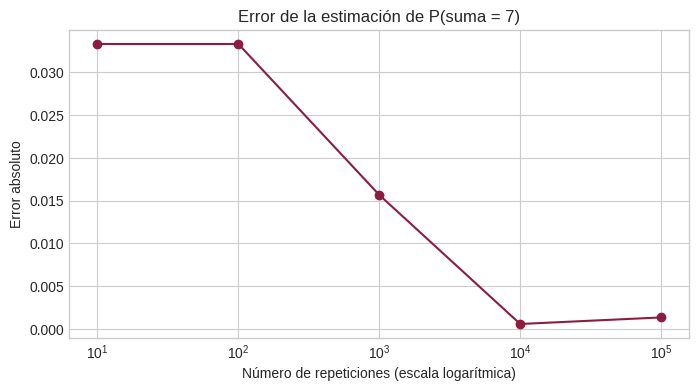

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(comparacion_simulacion["n"], comparacion_simulacion["error_absoluto"],
        marker="o", color="#8c1d40")
ax.set_xscale("log")
ax.set(title="Error de la estimación de P(suma = 7)",
       xlabel="Número de repeticiones (escala logarítmica)",
       ylabel="Error absoluto")
plt.show()

El error no tiene que disminuir en cada paso, pero su escala tiende a reducirse cuando aumenta $n$. Una estimación experimental es aproximada y depende de la muestra; el valor teórico se deriva del modelo.

## 15. Laboratorio integrador modificable

Este laboratorio permite cambiar el número de caras del dado, el número de lanzamientos por experimento y el evento de interés. El ejemplo calcula la probabilidad de que la suma de tres dados de seis caras sea al menos 15.

**Instrucciones**

1. Modifica `caras`, `numero_dados`, `umbral` o `repeticiones`.
2. Ejecuta la celda.
3. Compara el cálculo exacto con la simulación.
4. Explica cualquier diferencia sin atribuirla automáticamente a un error de código.

In [ ]:
# Parámetros modificables
caras = 6
numero_dados = 3
umbral = 15
repeticiones = 50_000

if caras < 2 or numero_dados < 1 or repeticiones < 1:
    raise ValueError("caras ≥ 2, numero_dados ≥ 1 y repeticiones ≥ 1.")

omega_lab = list(product(range(1, caras + 1), repeat=numero_dados))
evento_lab = [w for w in omega_lab if sum(w) >= umbral]
p_teorica_lab = len(evento_lab) / len(omega_lab)

muestra_lab = rng.integers(1, caras + 1, size=(repeticiones, numero_dados))
p_experimental_lab = np.mean(muestra_lab.sum(axis=1) >= umbral)

resultado_lab = pd.Series({
    "|Ω|": len(omega_lab),
    "casos favorables": len(evento_lab),
    "probabilidad teórica": p_teorica_lab,
    "probabilidad experimental": p_experimental_lab,
    "error absoluto": abs(p_experimental_lab - p_teorica_lab),
})
resultado_lab

,0
|Ω|,216.0000
casos favorables,20.0000
probabilidad teórica,0.0926
probabilidad experimental,0.0907
error absoluto,0.0019


**Interpretación del caso predeterminado.** El cálculo exacto enumera todos los resultados equiprobables; la simulación usa una muestra aleatoria. La cercanía entre ambos valores respalda la implementación, aunque no demuestra por sí sola que el modelo represente adecuadamente un dado físico.

**Actividad de extensión.** Sustituye el evento por “la suma es par” o “aparece al menos un seis”. Antes de ejecutar, formula $\Omega$ y el evento con notación de conjuntos y anticipa si la probabilidad será mayor o menor que $1/2$.

## 16. Conclusiones

La probabilidad se organiza mediante la terna $(\Omega,\mathcal{F},P)$: el espacio muestral describe los resultados, la familia de eventos determina qué subconjuntos se consideran y la medida asigna probabilidades de acuerdo con los axiomas.

El enfoque laplaciano funciona con resultados finitos equiprobables; el frecuentista interpreta la probabilidad a través de la estabilización de frecuencias; y el geométrico usa razones de medidas bajo uniformidad. La probabilidad condicional cambia el universo de referencia, la regla del producto encadena condiciones y la probabilidad total recompone un evento desde una partición.

Finalmente, independencia y exclusión mutua responden preguntas distintas: la primera se refiere a ausencia de influencia probabilística y la segunda a imposibilidad de ocurrencia conjunta. Las simulaciones permiten explorar y verificar cálculos, pero sus resultados siempre deben interpretarse dentro de los supuestos del modelo.

## 17. Bibliografía





- Rincón, Luis. *Introducción a la probabilidad*.
- Ross, Sheldon M. *A First Course in Probability*.
- Mood, Alexander M.; Graybill, Franklin A.; y Boes, Duane C. Obra de probabilidad y estadística indicada como respaldo formal.

